In [1]:
import numpy as np
import cv2
from google.colab.patches import cv2_imshow
import matplotlib.pyplot as plt
from IPython.display import display
import ipywidgets as widgets
%matplotlib inline
from ipywidgets import interactive

In [2]:
def FFT(x):
    '''
    Helper function to compute 1D-FFT
    '''

    N = len(x)

    if(N == 1):
        return x
    else:
        X_even = FFT(x[::2])
        X_odd = FFT(x[1::2])
        factors = np.exp(-2*1j*np.pi*np.arange(N)/N)

        X = np.concatenate(
            [X_even + factors[:int(N//2)]*X_odd,
             X_even - factors[:int(N//2)]*X_odd]
        )

        return X

In [3]:
def IFFT(x):
    '''
    Helper function to compute 1D-IFFT
    '''

    N = len(x)

    if(N == 1):
        return x;
    else:
        X_even = IFFT(x[::2])
        X_odd = IFFT(x[1::2])
        factors = np.exp(2*1j*np.pi*np.arange(N)/N)

        X = np.concatenate(
            [X_even + factors[:int(N/2)]*X_odd,
             X_even - factors[:int(N/2)]*X_odd]
        )

        return X;

In [4]:
def FFT2d(img:np.ndarray,shift:bool = True):
    '''
    Computes 2D-FFT of given N*N array where N is a power of 2,
    shift centers the FFT if set to true
    '''

    # Check if the FFT needs to be centered
    if(shift):
        mask = np.array([[(-1)**(i+j) for i in range(img.shape[0])] for j in range(img.shape[1])])
        # Multiply each pixel (x,y) with (-1)^(x+y)
        # This centers the spectrum when FFT is computed
        img = np.multiply(mask,img)

    # Calculate Row wise 1D FFT and take transpose to transform columns to rows
    intr = np.array([FFT(row) for row in img]).T # Intermediate Transform

    # Calculate Columwise wise 1D FFT
    fft = np.array([FFT(row) for row in intr]) # Final Transform

    return fft.T

In [5]:
def IFFT2d(IMG:np.ndarray,shift:bool = True):
    '''
    Computes 2D-IFFT of given N*N array where N is a power of 2,
    shift is set to True if the spectrum is centered
    '''

    # Calculate Row wise 1D IFFT and take transpose to transform columns to rows
    intr = np.array([IFFT(row) for row in IMG]).T # Intermediate Transform

    # Calculate Columwise wise 1D IFFT
    ifft = np.array([IFFT(row) for row in intr]) # Final Transform

    # Check if the FFT is centered
    if(shift):
        mask = np.array([[(-1)**(i+j) for i in range(IMG.shape[0])] for j in range(IMG.shape[1])])
        # Multiply each pixel (x,y) with (-1)^(x+y)
        # This reverses the centering done by FFT function
        ifft = np.multiply(ifft,mask)

    return ifft.T/(IMG.shape[0]**2)

array([[156, 158, 160, ..., 152, 152, 152],
       [156, 157, 159, ..., 152, 152, 152],
       [158, 156, 156, ..., 152, 152, 152],
       ...,
       [120, 123, 127, ..., 121, 113, 111],
       [121, 123, 125, ..., 121, 113, 111],
       [121, 123, 126, ..., 121, 113, 111]], dtype=uint8)
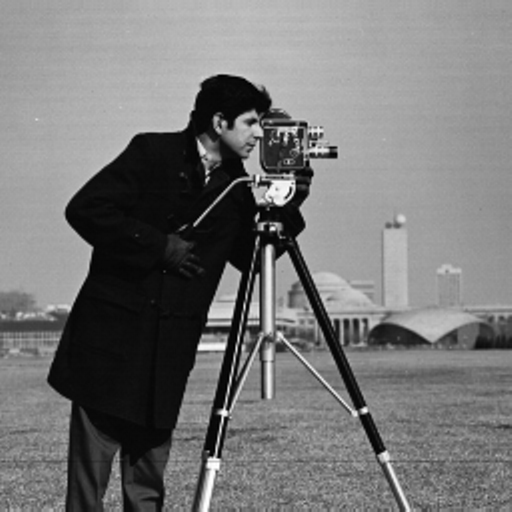

In [6]:
img = cv2.imread("cameraman.jpg",cv2.IMREAD_GRAYSCALE)
img

In [7]:
IMG = FFT2d(img)

In [8]:
def ideal_lpf(file_path:str,cut_off:float):
    img = cv2.imread(file_path,cv2.IMREAD_GRAYSCALE)

    IMG = FFT2d(img)

    fltrd_fft = np.zeros_like(IMG)

    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            d = ((i - (img.shape[0])/2)**2 + (j - (img.shape[1])/2)**2)**(0.5)
            if(d <= cut_off):
                fltrd_fft[i][j] =  IMG[i][j]

    fltrd_img = IFFT2d(fltrd_fft)

    return fltrd_img


In [9]:
def ideal_hpf(file_path:str,cut_off:float):
    img = cv2.imread(file_path,cv2.IMREAD_GRAYSCALE)

    IMG = FFT2d(img)

    fltrd_fft = np.zeros_like(IMG)

    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            d = ((i - (img.shape[0])/2)**2 + (j - (img.shape[1])/2)**2)**(0.5)
            if(d > cut_off):
                fltrd_fft[i][j] =  IMG[i][j]

    fltrd_img = IFFT2d(fltrd_fft)

    return fltrd_img

In [10]:
lpf_img = ideal_lpf("cameraman.jpg",50)
hpf_img = ideal_hpf("cameraman.jpg",50)

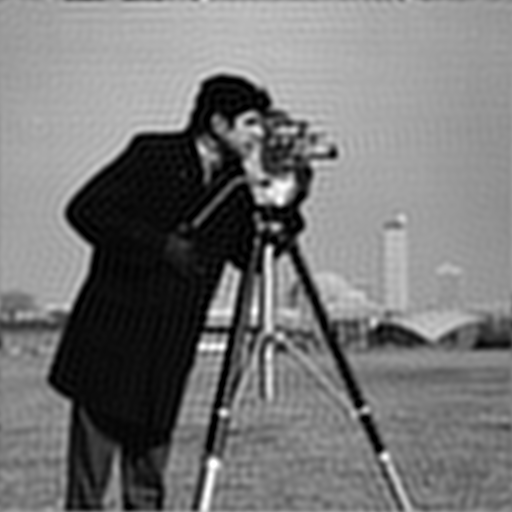

In [11]:
# plt.imshow(lpf_img.real,cmap = "gray")
cv2_imshow(lpf_img.real)

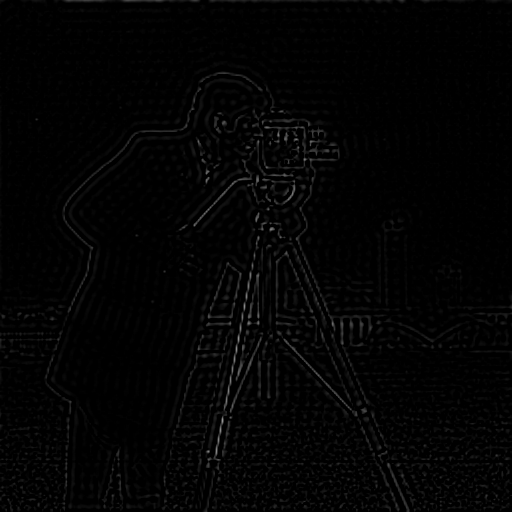

In [12]:
# plt.imshow(hpf_img.real,cmap = "gray")
cv2_imshow(hpf_img.real)

In [13]:
def gaussian_lpf(file_path:str,cut_off):
    img = cv2.imread(file_path,cv2.IMREAD_GRAYSCALE)

    IMG = FFT2d(img)

    fltrd_fft = np.zeros_like(IMG)

    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            d = ((i - (img.shape[0])/2)**2 + (j - (img.shape[1])/2)**2)**(0.5)
            fltrd_fft[i][j] = np.exp(-(d**2)/(2*(cut_off**2)))*IMG[i][j]

    fltrd_img = IFFT2d(fltrd_fft)

    return fltrd_img

In [14]:
def gaussian_hpf(file_path:str,cut_off):
    img = cv2.imread(file_path,cv2.IMREAD_GRAYSCALE)

    IMG = FFT2d(img)

    fltrd_fft = np.zeros_like(IMG)

    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            d = ((i - (img.shape[0])/2)**2 + (j - (img.shape[1])/2)**2)**(0.5)
            fltrd_fft[i][j] = (1 - np.exp(-(d**2)/(2*(cut_off**2))))*IMG[i][j]

    fltrd_img = IFFT2d(fltrd_fft)

    return fltrd_img

In [15]:
lpf_img = gaussian_lpf("cameraman.jpg",50)

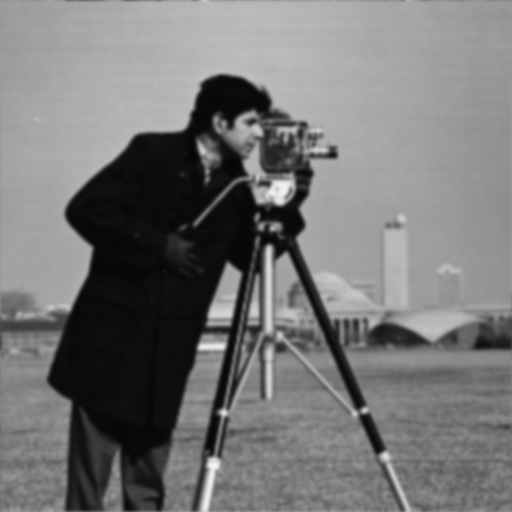

In [16]:
# plt.imshow(lpf_img.real,cmap = "gray")
cv2_imshow(lpf_img.real)

In [17]:
hpf_img = gaussian_hpf("cameraman.jpg",50)

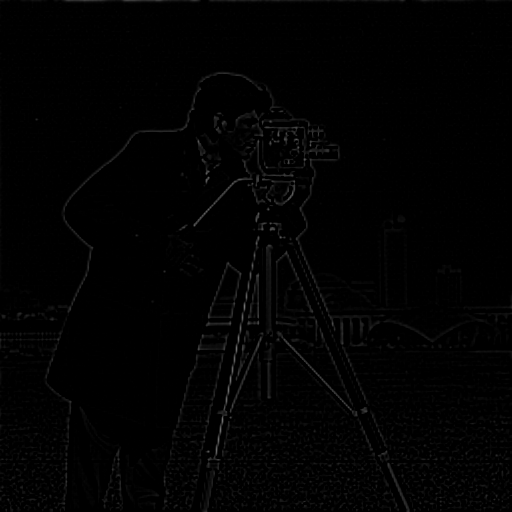

In [18]:
# plt.imshow(hpf_img.real,cmap = "gray")
cv2_imshow(hpf_img.real)

In [19]:
def butterworth(d:float,cut_off:float,N:int = 2):
    return 1/(1 + (d/cut_off)**(2*N))

In [20]:
def butterworth_lpf(file_path:str,cut_off:float,order:int = 2):
    img = cv2.imread(file_path,cv2.IMREAD_GRAYSCALE)

    IMG = FFT2d(img)

    fltrd_fft = np.zeros_like(IMG)

    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            d = ((i - (img.shape[0])/2)**2 + (j - (img.shape[1])/2)**2)**(0.5)
            fltrd_fft[i][j] = butterworth(d,cut_off,order)*IMG[i][j]

    fltrd_img = IFFT2d(fltrd_fft)

    return fltrd_img

In [21]:
lpf_img = butterworth_lpf("cameraman.jpg",50)

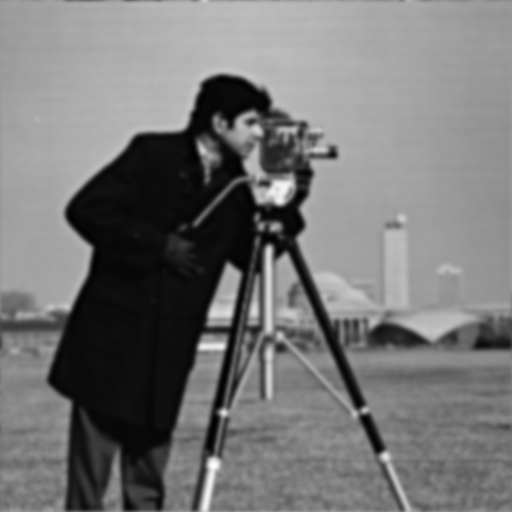

In [22]:
# plt.imshow(lpf_img.real,cmap = "gray")
cv2_imshow(lpf_img.real)

In [23]:
def butterworth_hpf(file_path:str,cut_off:float,order:int = 2):
    img = cv2.imread(file_path,cv2.IMREAD_GRAYSCALE)

    IMG = FFT2d(img)

    fltrd_fft = np.zeros_like(IMG)

    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            d = ((i - (img.shape[0])/2)**2 + (j - (img.shape[1])/2)**2)**(0.5)
            fltrd_fft[i][j] = (1 - butterworth(d,cut_off,order))*IMG[i][j]

    fltrd_img = IFFT2d(fltrd_fft)

    return fltrd_img

In [24]:
hpf_img = butterworth_hpf("cameraman.jpg",50)

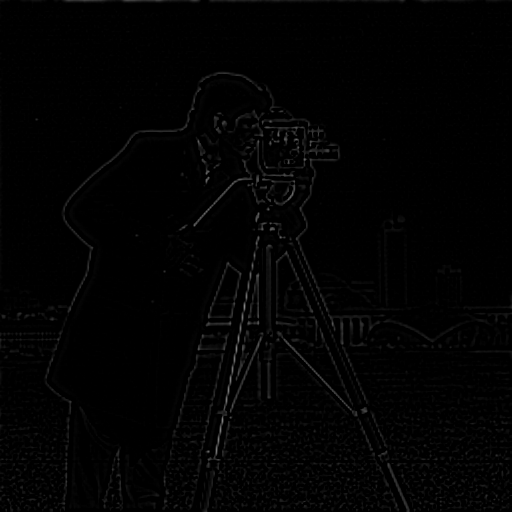

In [25]:
# plt.imshow(hpf_img.real,cmap = "gray")
cv2_imshow(hpf_img.real)

In [26]:
def filter_intr(img_path:list,filter_type:list,passtype:list,cut_off:float,order:int):
    if passtype == 'high':
        if(filter_type =="Gauss" ):
            img = gaussian_hpf(img_path,cut_off)
        elif(filter_type == "Butterworth"):
            img  = butterworth_hpf(img_path,cut_off,order)
        elif(filter_type =="Ideal"):
            img = ideal_hpf(img_path,cut_off)
        else:
            print("Invalid Choice")
    if passtype == 'low':
        if(filter_type =="Gauss" ):
            img = gaussian_lpf(img_path,cut_off)
        elif(filter_type == "Butterworth"):
            img  = butterworth_lpf(img_path,cut_off,order)
        elif(filter_type =="Ideal"):
            img = ideal_lpf(img_path,cut_off)
        else:
            print("Invalid Choice")

    # plt.imshow(img.real,cmap = "gray")
    # plt.show()
    cv2_imshow(img.real)

img_list = ["cameraman.jpg","jetplane.jpg","lake.jpg","lena.jpg","livingroom.jpg","mandril.jpg","pirate.jpg","walkbridge.jpg"]
filter_types = ["Gauss","Butterworth","Ideal"]
passtypes = ["high","low"]
order = widgets.IntSlider(min=1, max=10, step=1, value = 2)

interactive_plot = interactive(filter_intr,img_path = img_list,filter_type = filter_types,passtype = passtypes,cut_off = (0.0, 100.0), order = order)

In [27]:
interactive_plot

interactive(children=(Dropdown(description='img_path', options=('cameraman.jpg', 'jetplane.jpg', 'lake.jpg', '…

In [28]:
ein = cv2.imread("einstein.png",cv2.IMREAD_GRAYSCALE)
mar = cv2.imread("marilyn.png",cv2.IMREAD_GRAYSCALE)

In [29]:
def gaussian(D:float,cut_off:float):
    return np.exp(-(D**2)/(2*(cut_off**2)))

In [30]:
def gauss_lpf(IMG:np.ndarray,cut_off:float):
    fltrd_fft = np.zeros_like(IMG)

    for i in range(IMG.shape[0]):
        for j in range(IMG.shape[1]):
            d = ((i - (IMG.shape[0])/2)**2 + (j - (IMG.shape[1])/2)**2)**(0.5)
            fltrd_fft[i][j] = gaussian(d,cut_off)*IMG[i][j]

    return fltrd_fft

In [31]:
def gauss_hpf(IMG:np.ndarray,cut_off:float):
    fltrd_fft = np.zeros_like(IMG)

    for i in range(IMG.shape[0]):
        for j in range(IMG.shape[1]):
            d = ((i - (IMG.shape[0])/2)**2 + (j - (IMG.shape[1])/2)**2)**(0.5)
            fltrd_fft[i][j] = (1 - gaussian(d,cut_off))*IMG[i][j]

    return fltrd_fft

In [32]:
def create_hybrid_img(img_path1:str,img_path2:str,cut_off:float = 50):
    img1 = cv2.imread(img_path1,cv2.IMREAD_GRAYSCALE)
    img2 = cv2.imread(img_path2,cv2.IMREAD_GRAYSCALE)

    IMG1 = np.fft.fftshift(np.fft.fft2(img1))
    IMG2 = np.fft.fftshift(np.fft.fft2(img2))

    lp_IMG2 = gauss_lpf(IMG2,cut_off)
    hp_IMG1 = gauss_hpf(IMG1,cut_off)

    lp_img2 = np.fft.ifft2(np.fft.ifftshift(lp_IMG2))
    hp_img1 = np.fft.ifft2(np.fft.ifftshift(hp_IMG1))

    res = np.abs(lp_img2.real) + np.abs(hp_img1.real)

    return res


In [33]:
hybd = create_hybrid_img("einstein.png","marilyn.png",7.5)

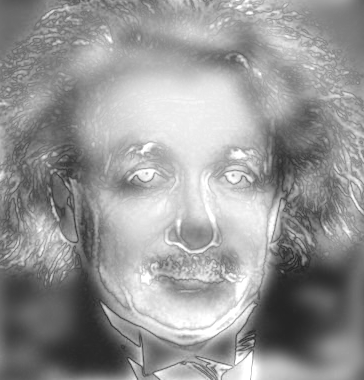

In [34]:
cv2_imshow(hybd)

In [35]:
#file_path1 - High pass filter is used on image
#file_path2 - Low pass filter is used on image
def create_hybrid_img_intr(threshold:float,file_path1:list,file_path2:list):
    img = create_hybrid_img(file_path1,file_path2,threshold)
    # plt.imshow(img.real,cmap = "gray")
    # plt.show()
    cv2_imshow(img.real)

interactive_plot = interactive(create_hybrid_img_intr, threshold = (0.0, 20.0),file_path1 = ["einstein.png","marilyn.png"],file_path2=["einstein.png","marilyn.png"])

In [36]:
interactive_plot

interactive(children=(FloatSlider(value=10.0, description='threshold', max=20.0), Dropdown(description='file_p…

In [37]:
cam_n = cv2.imread("cameraman_noisy1.jpg",cv2.IMREAD_GRAYSCALE)
cam_dn = cv2.imread("cameraman_noisy2.jpg",cv2.IMREAD_GRAYSCALE)

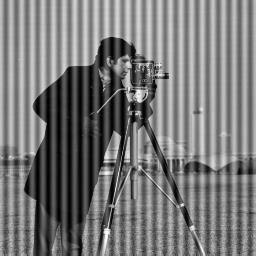

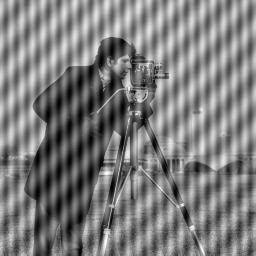

In [38]:
cv2_imshow(cam_n)
cv2_imshow(cam_dn)

In [39]:
mag_n = np.log(np.abs(FFT2d(cam_n)))
mag_dn = np.log(np.abs(FFT2d(cam_dn)))

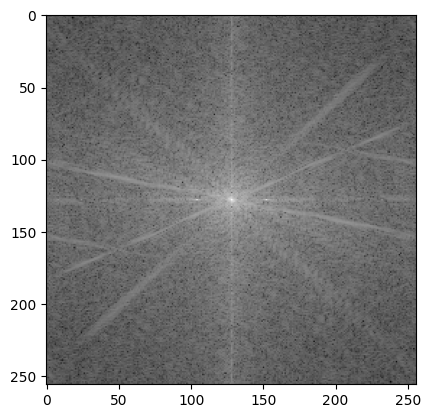

In [40]:
plt.imshow(mag_n,cmap = "gray")

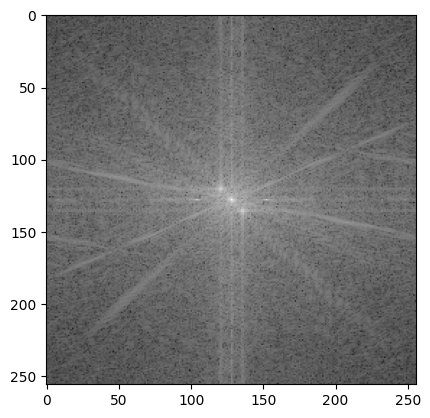

In [41]:
plt.imshow(mag_dn,cmap = "gray")

In [42]:
def de_noise(file_path:str,threshold:float):
    img = cv2.imread(file_path,cv2.IMREAD_GRAYSCALE)

    IMG = np.fft.fftshift(np.fft.fft2(img))

    mag = np.log(np.abs(IMG))

    mask = (mag > threshold).astype(np.uint8)

    mask = 1 - mask

    dc = IMG[IMG.shape[0]//2][IMG.shape[1]//2]

    IMG = IMG*mask

    IMG[IMG.shape[0]//2][IMG.shape[1]//2] = dc

    de_img = np.fft.ifft2(np.fft.ifftshift(IMG))

    return de_img

In [43]:
def de_noise_intr(threshold:float,file_paths:list):
    img = de_noise(file_paths,threshold)
    # plt.imshow(img.real,cmap = "gray")
    # plt.show()
    cv2_imshow(img.real)

interactive_plot = interactive(de_noise_intr, threshold = (0.0, 20.0),file_paths = ["cameraman_noisy1.jpg","cameraman_noisy2.jpg"])

In [44]:
interactive_plot

interactive(children=(FloatSlider(value=10.0, description='threshold', max=20.0), Dropdown(description='file_p…